In [1]:
%load_ext autoreload
%autoreload 2

## Labeling KL Bonding/Antibonding

In [2]:
import os
import sys
import glob
import torch
import time
from cace.tasks import LightningTrainingTask
from deeporb.data import OrbDataset, OrbData
from deeporb.ceonet import CEONet
from cace.models import NeuralNetworkPotential
from deeporb.atomwise import AttentionAtomwise
from cace.tasks import GetLoss
from deeporb.metrics import Metrics

on_cluster = False
if 'SLURM_JOB_CPUS_PER_NODE' in os.environ.keys():
    on_cluster = True
if on_cluster:
    root = os.environ["SCRATCH"] + "/data"
else:
    root = "/home/king1305/ORBITAL_LABELING/deeporb2/data/"

#Change here!
TRAINING_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 0.1

LOGS_NAME = "kl_label"
DATA_NAME = "kl_constructed.h5"

CUTOFF = 7.6
LINMAX = 2
LOMAX = 2
NC = 16
LAYERS = 1
N_RBF = 16
N_RSAMPLES = 16
STACKING = True
IRREP_MIXING = False
CHARGE_EMBEDDING = False

BATCH_SIZE = 64
AVGE0 = 0
SIGMA = 1

DEV_RUN = False
LR = 0.001
MAX_EPOCHS = 1000

torch.multiprocessing.set_sharing_strategy('file_system')
print("Making dataset...")
time_start = time.perf_counter()
data = OrbData(data_path=f"{root}/{DATA_NAME}",train_split=TRAINING_SIZE,val_split=VAL_SIZE,test_split=TEST_SIZE,
               batch_size=BATCH_SIZE,cutoff=CUTOFF,avge0=AVGE0,sigma=SIGMA)
data.setup()
time_stop = time.perf_counter()
print("Time elapsed:",time_stop-time_start)

representation = CEONet(NC,cutoff=CUTOFF,n_rbf=N_RBF,n_rsamples=N_RSAMPLES,stacking=STACKING,irrep_mixing=IRREP_MIXING,
                        linmax=LINMAX,lomax=LOMAX,layers=LAYERS,charge_embedding=CHARGE_EMBEDDING)

from cace.models import NeuralNetworkPotential
from deeporb.atomwise import AttentionAtomwise

atomwise_label = AttentionAtomwise(
                    output_key='pred_label_logit',
                    n_hidden=[32,16],
                    n_out=4,
                    attention_hidden_nc=128,
                    bias=True
                   )

model = NeuralNetworkPotential(
    input_modules=None,
    representation=representation,
    output_modules=[atomwise_label]
)

/home/king1305/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/king1305/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Making dataset...


/home/king1305/.local/lib/python3.10/site-packages/matscipy/neighbours.py:718: RuntimeWarning: Ratio of simulation cell size to cutoff is very large; reducing number of bins for neighbour list search, but this may be slow. Are you using a cell with lots of vacuum?
  return ffi.neighbour_list(quantities, cell_origin, cell,


Time elapsed: 131.6399607269559


In [4]:
import torch
pred, ref = [], []
state_dict = torch.load("../model_eval/kl_labels/best_model_state.pth")
model.load_state_dict(state_dict)
model.cuda()
with torch.no_grad():
    for batch in data.test_dataloader():
        batch.cuda()
        ref.append(batch["label"])
        out = model(batch)
        pred.append(out["pred_label_logit"].argmax(axis=1))
torch.cuda.empty_cache()
pred = torch.hstack(pred)
ref = torch.hstack(ref)

/tmp/ipykernel_2577801/3821475768.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../model_eval/kl_labels/best_model_state.pth")


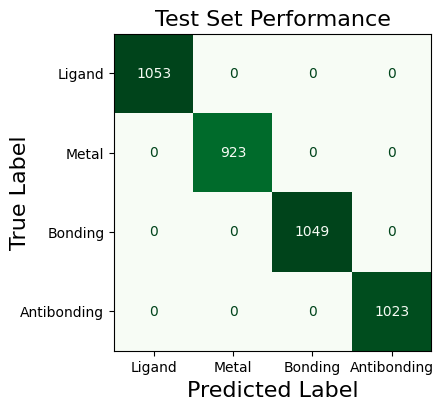

In [6]:
fs=16
# fs2 = 
djvfont = {'fontname':'DejaVu Sans'}

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming you have your true labels and predicted labels
y_true = ref.cpu()
y_pred = pred.cpu()

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(4.5,4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax,colorbar=False,cmap='Greens')
plt.xticks([0,1,2,3],["Ligand","Metal","Bonding","Antibonding"],**djvfont)
plt.yticks([0,1,2,3],["Ligand","Metal","Bonding","Antibonding"],**djvfont)
# plt.show()
plt.title("Test Set Performance",fontsize=fs)
plt.xlabel("Predicted Label",fontsize=fs)
plt.ylabel("True Label",fontsize=fs,labelpad=-7)
plt.tight_layout()
plt.savefig("../figures/tm_class_acc.png",dpi=500)